# Cardiometabolic Risk Stratification & Prevention Intelligence
## Exploratory Data Analysis

# STEP 1 - Setup & Import

In [1]:
## Setup & import libraries

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


## define the location of our raw and processed 
DATA_RAW = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "processed")
os.makedirs(DATA_PROCESSED, exist_ok=True)

### STEP 2 - Load NHANES Datasets

In [2]:
demo = pd.read_sas(os.path.join(DATA_RAW, "DEMO_J.xpt"))
bmx = pd.read_sas(os.path.join(DATA_RAW, "BMX_J.xpt"))
bpx = pd.read_sas(os.path.join(DATA_RAW, "BPX_J.xpt"))
glu = pd.read_sas(os.path.join(DATA_RAW, "GLU_J.xpt"))
ghb = pd.read_sas(os.path.join(DATA_RAW, "GHB_J.xpt"))
tchol = pd.read_sas(os.path.join(DATA_RAW, "TCHOL_J.xpt"))
hdl = pd.read_sas(os.path.join(DATA_RAW, "HDL_J.xpt"))
trigly = pd.read_sas(os.path.join(DATA_RAW, "TRIGLY_J.xpt"))
smq = pd.read_sas(os.path.join(DATA_RAW, "SMQ_J.xpt"))
paq = pd.read_sas(os.path.join(DATA_RAW, "PAQ_J.xpt"))
bpq = pd.read_sas(os.path.join(DATA_RAW, "BPQ_J.xpt"))
diq = pd.read_sas(os.path.join(DATA_RAW, "DIQ_J.xpt"))

In [10]:
#  - Standardize column names

datasets = {
    "demo": demo,
    "bmx": bmx,
    "bpx": bpx,
    "glu": glu,
    "ghb": ghb,
    "tchol": tchol,
    "hdl": hdl,
    "trigly": trigly,
    "smq": smq,
    "paq": paq,
    "bpq": bpq,
    "diq": diq
}

for name, df in datasets.items():
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.lower()
    )

In [11]:
# step 2a select relevant columns
demo = demo[["seqn","riagendr","ridageyr","ridreth3","dmdeduc2","indfmpir"]]
bmx = bmx[["seqn","bmxbmi","bmxwaist","bmxwt","bmxht"]]
bpx = bpx[["seqn","bpxsy1","bpxdi1"]]
glu = glu[["seqn","lbxglu"]]
ghb = ghb[["seqn","lbxgh"]]
tchol = tchol[["seqn","lbxtc"]]
hdl = hdl[["seqn","lbdhdd"]]
trigly = trigly[["seqn","lbxtr","lbdldl"]]
smq = smq[["seqn","smq020"]]
paq = paq[["seqn","paq650","paq665"]]
bpq = bpq[["seqn","bpq020","bpq040a"]]
diq = diq[["seqn","diq010"]]

In [12]:
# STEP 2b - Dataset Overview

datasets = {
    "demo": demo,
    "bmx": bmx,
    "bpx": bpx,
    "glu": glu,
    "ghb": ghb,
    "tchol": tchol,
    "hdl": hdl,
    "trigly": trigly,
    "smq": smq,
    "paq": paq,
    "bpq": bpq,
    "diq": diq
}


for name, df in datasets.items():
    print(f"{name:<10} {df.shape[0]:>6} rows {df.shape[1]:>3} cols")

demo         9254 rows   6 cols
bmx          8704 rows   5 cols
bpx          8704 rows   3 cols
glu          3036 rows   2 cols
ghb          6401 rows   2 cols
tchol        7435 rows   2 cols
hdl          7435 rows   2 cols
trigly       3036 rows   3 cols
smq          6724 rows   2 cols
paq          5856 rows   3 cols
bpq          6161 rows   3 cols
diq          8897 rows   2 cols


In [7]:
# STEP 2c - Data Inspection

for name, df in datasets.items():

    print(f"\n{name}")

    missing_pct = (
        df.isnull().sum()
        / len(df)
        * 100
    ).round(2)

    print(missing_pct)
    


demo
SEQN         0.00
SDDSRVYR     0.00
RIDSTATR     0.00
RIAGENDR     0.00
RIDAGEYR     0.00
RIDAGEMN    93.55
RIDRETH1     0.00
RIDRETH3     0.00
RIDEXMON     5.94
RIDEXAGM    62.90
DMQMILIZ    35.12
DMQADFC     93.94
DMDBORN4     0.00
DMDCITZN     0.03
DMDYRSUS    78.95
DMDEDUC3    75.08
DMDEDUC2    39.82
DMDMARTL    39.82
RIDEXPRG    88.01
SIALANG      0.00
SIAPROXY     0.00
SIAINTRP     0.00
FIALANG      5.12
FIAPROXY     5.12
FIAINTRP     5.12
MIALANG     27.77
MIAPROXY    27.77
MIAINTRP    27.77
AIALANGA    46.22
DMDHHSIZ     0.00
DMDFMSIZ     0.00
DMDHHSZA     0.00
DMDHHSZB     0.00
DMDHHSZE     0.00
DMDHRGND     0.00
DMDHRAGZ     0.00
DMDHREDZ     5.30
DMDHRMAZ     2.06
DMDHSEDZ    48.66
WTINT2YR     0.00
WTMEC2YR     0.00
SDMVPSU      0.00
SDMVSTRA     0.00
INDHHIN2     5.31
INDFMIN2     5.12
INDFMPIR    13.30
dtype: float64

bmx
SEQN          0.00
BMDSTATS      0.00
BMXWT         1.42
BMIWT        95.22
BMXRECUM     89.73
BMIRECUM     99.72
BMXHEAD      97.77
BMIHEAD     1

In [15]:
# map demography columns

# Gender (RIAGENDR)

gender_map = {
    1: "Male",
    2: "Female"
}

demo["riagendr"] = demo["riagendr"].map(gender_map)


# Ethnicity (RIDRETH3)

ethnicity_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other/Multiracial"
}

demo["ridreth3"] = demo["ridreth3"].map(ethnicity_map)

### STEP 3  - Demographic EDA Analysis

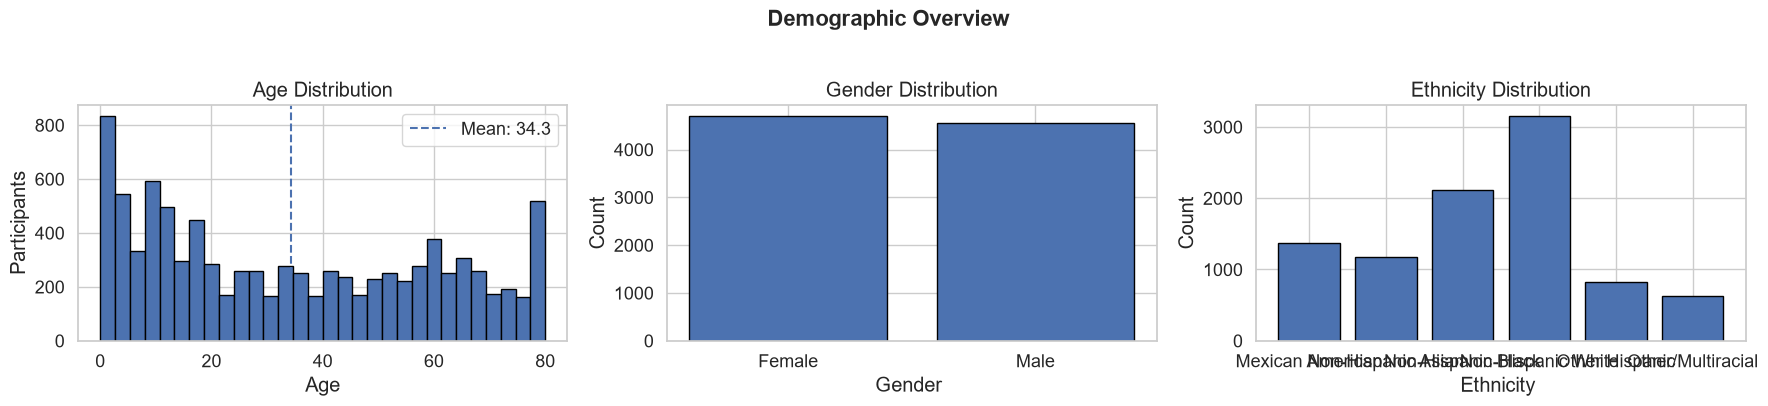

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Age
data = demo["ridageyr"].dropna()

axes[0].hist(data, bins=30, edgecolor="black")
axes[0].axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")
axes[0].set(title="Age Distribution", xlabel="Age", ylabel="Participants")
axes[0].legend()

# Gender
gender_counts = demo["riagendr"].value_counts().sort_index()

axes[1].bar(gender_counts.index.astype(str), gender_counts.values, edgecolor="black")
axes[1].set(title="Gender Distribution", xlabel="Gender ", ylabel="Count")

# Ethnicity
ethnicity_counts = demo["ridreth3"].value_counts().sort_index()

axes[2].bar(ethnicity_counts.index.astype(str), ethnicity_counts.values, edgecolor="black")
axes[2].set(title="Ethnicity Distribution", xlabel="Ethnicity ", ylabel="Count")

plt.suptitle("Demographic Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 4 - Body Measures EDA

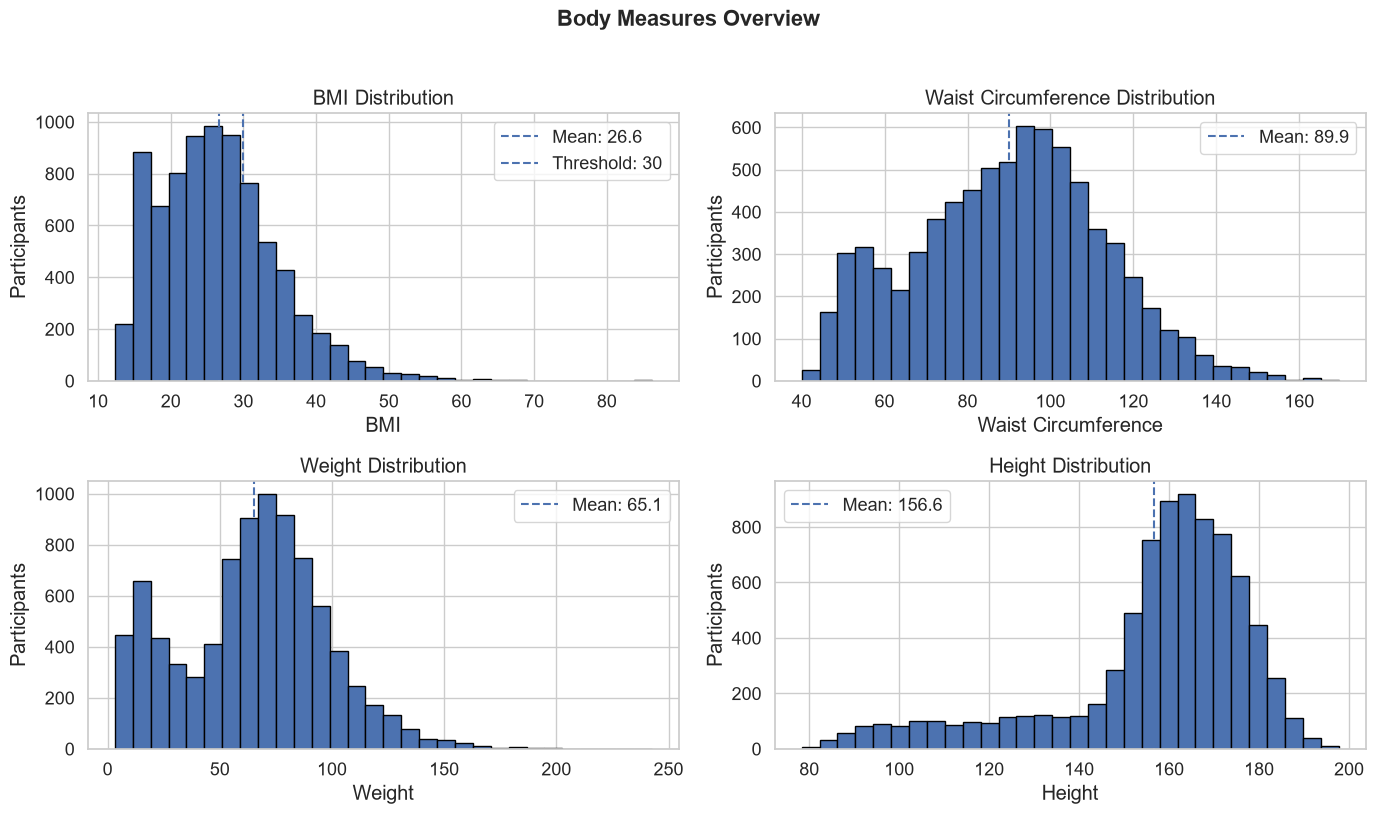

In [18]:
body_measure_cols = [
    ("bmxbmi", "BMI Distribution", "BMI", 30),
    ("bmxwaist", "Waist Circumference Distribution", "Waist Circumference", None),
    ("bmxwt", "Weight Distribution", "Weight", None),
    ("bmxht", "Height Distribution", "Height", None)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, title, xlabel, threshold) in zip(axes, body_measure_cols):

    data = bmx[col].dropna()

    ax.hist(data, bins=30, edgecolor="black")
    ax.axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")

    if threshold is not None:
        ax.axvline(threshold, linestyle="dashed", label=f"Threshold: {threshold}")

    ax.set(title=title, xlabel=xlabel, ylabel="Participants")
    ax.legend()

plt.suptitle("Body Measures Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 4 - Blood Pressure EDA

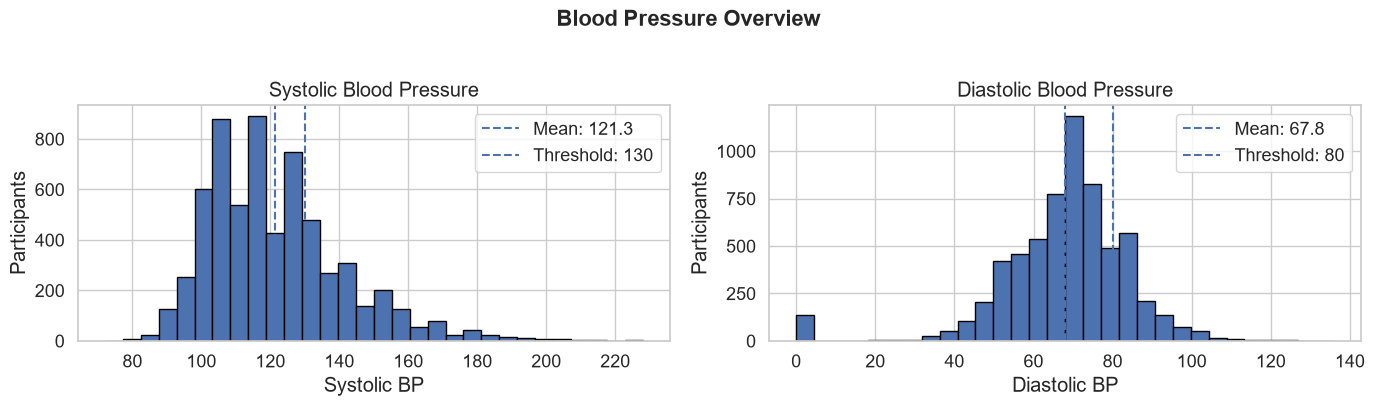

In [19]:
bp_cols = [
    ("bpxsy1", "Systolic Blood Pressure", "Systolic BP", 130),
    ("bpxdi1", "Diastolic Blood Pressure", "Diastolic BP", 80)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, title, xlabel, threshold) in zip(axes, bp_cols):

    data = bpx[col].dropna()

    ax.hist(data, bins=30, edgecolor="black")
    ax.axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")
    ax.axvline(threshold, linestyle="dashed", label=f"Threshold: {threshold}")

    ax.set(title=title, xlabel=xlabel, ylabel="Participants")
    ax.legend()

plt.suptitle("Blood Pressure Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 5 - Diabetes Risk Markers EDA

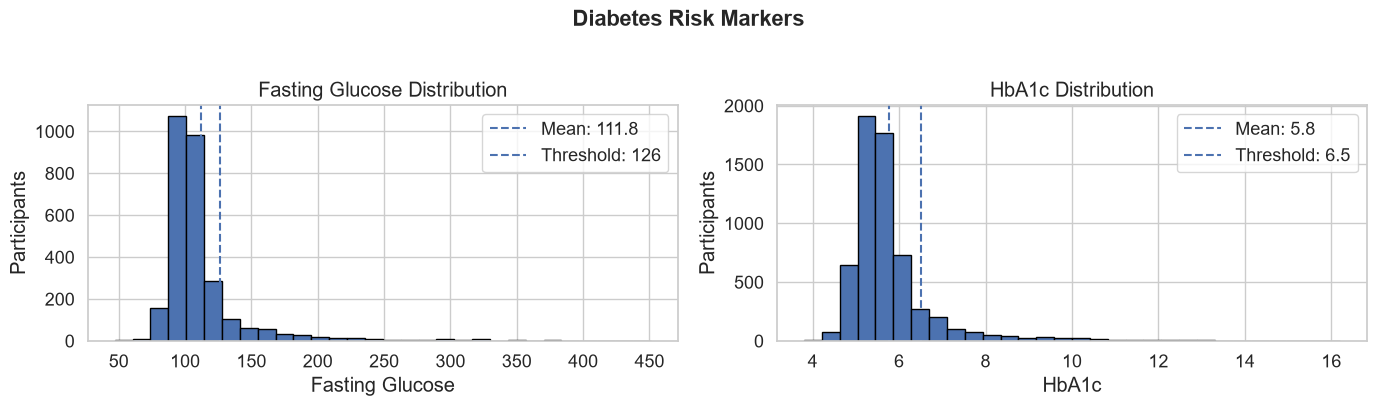

In [20]:

diabetes_markers = [
    (glu, "lbxglu", "Fasting Glucose Distribution", "Fasting Glucose", 126),
    (ghb, "lbxgh", "HbA1c Distribution", "HbA1c", 6.5)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (df, col, title, xlabel, threshold) in zip(axes, diabetes_markers):

    data = df[col].dropna()

    ax.hist(data, bins=30, edgecolor="black")
    ax.axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")
    ax.axvline(threshold, linestyle="dashed", label=f"Threshold: {threshold}")

    ax.set(title=title, xlabel=xlabel, ylabel="Participants")
    ax.legend()

plt.suptitle("Diabetes Risk Markers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 6 - Lipid Marker EDA

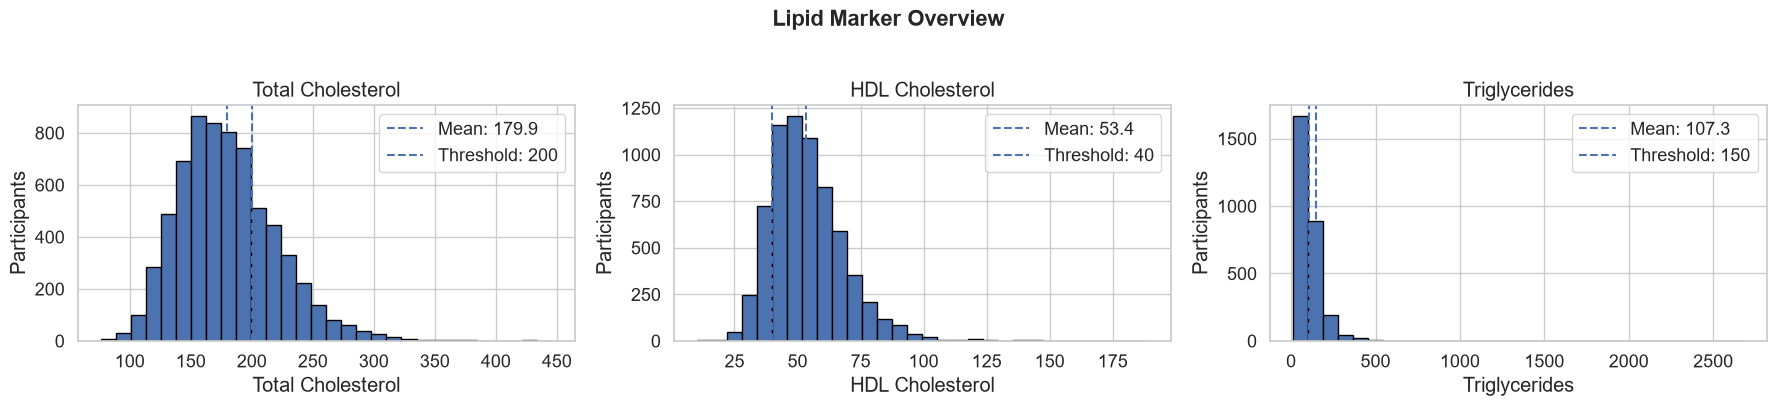

In [21]:
lipid_markers = [
    (tchol, "lbxtc", "Total Cholesterol", "Total Cholesterol", 200),
    (hdl, "lbdhdd", "HDL Cholesterol", "HDL Cholesterol", 40),
    (trigly, "lbxtr", "Triglycerides", "Triglycerides", 150)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (df, col, title, xlabel, threshold) in zip(axes, lipid_markers):

    data = df[col].dropna()

    ax.hist(data, bins=30, edgecolor="black")
    ax.axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")
    ax.axvline(threshold, linestyle="dashed", label=f"Threshold: {threshold}")

    ax.set(title=title, xlabel=xlabel, ylabel="Participants")
    ax.legend()

plt.suptitle("Lipid Marker Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# STEP 7 - Lifestyle Questionnaire EDA
- 1 - YES
- 2 - N0

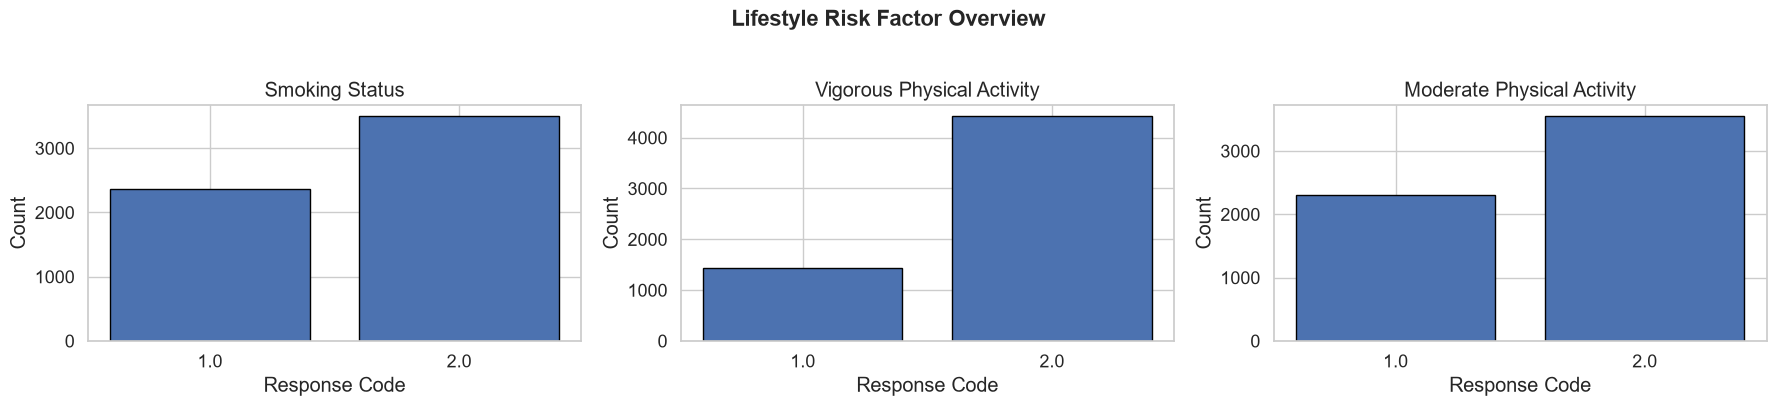

In [22]:
lifestyle_vars = [
    (smq, "smq020", "Smoking Status"),
    (paq, "paq650", "Vigorous Physical Activity"),
    (paq, "paq665", "Moderate Physical Activity")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (df, col, title) in zip(axes, lifestyle_vars):

    if col in df.columns:
        counts = df[col].value_counts().sort_index()

        ax.bar(counts.index.astype(str), counts.values, edgecolor="black")
        ax.set(title=title, xlabel="Response Code", ylabel="Count")

plt.suptitle("Lifestyle Risk Factor Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 8 - Medical History Questionnaire EDA

- 1 - YES
- 2 - NO
- 3 - BORDERLINE


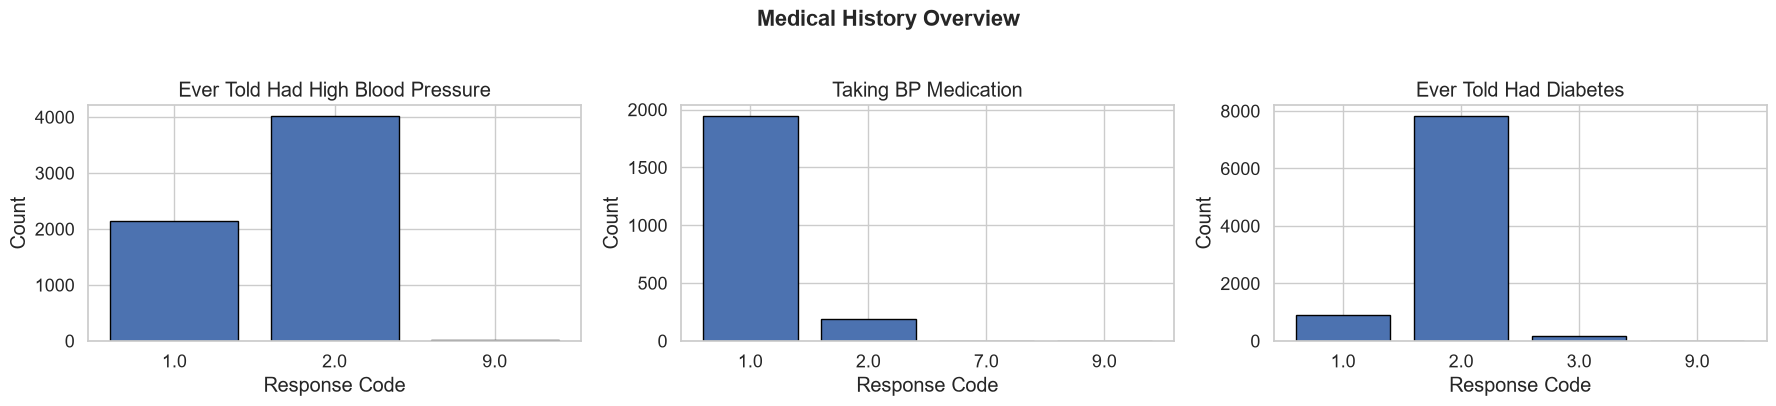

In [24]:
medical_history_vars = [
    (bpq, "bpq020", "Ever Told Had High Blood Pressure"),
    (bpq, "bpq040a", "Taking BP Medication"),
    (diq, "diq010", "Ever Told Had Diabetes")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (df, col, title) in zip(axes, medical_history_vars):

    if col in df.columns:
        counts = df[col].value_counts().sort_index()

        ax.bar(counts.index.astype(str), counts.values, edgecolor="black")
        ax.set(title=title, xlabel="Response Code", ylabel="Count")

plt.suptitle("Medical History Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 9 - Socioeconomic Inequality EDA

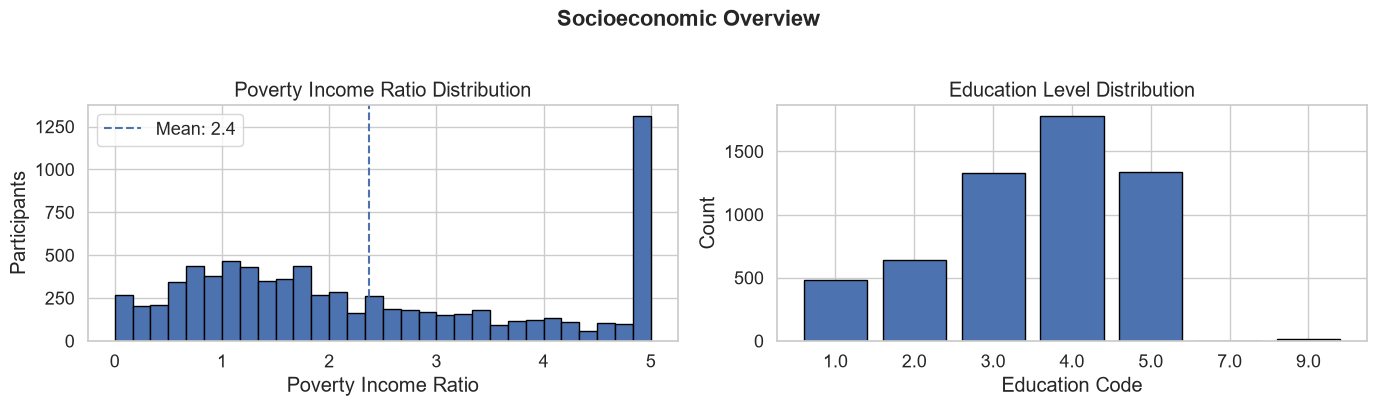

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Poverty Income Ratio
data = demo["indfmpir"].dropna()

axes[0].hist(data, bins=30, edgecolor="black")
axes[0].axvline(data.mean(), linestyle="dashed", label=f"Mean: {data.mean():.1f}")
axes[0].set(title="Poverty Income Ratio Distribution", xlabel="Poverty Income Ratio", ylabel="Participants")
axes[0].legend()

# Education
education_counts = demo["dmdeduc2"].value_counts().sort_index()

axes[1].bar(education_counts.index.astype(str), education_counts.values, edgecolor="black")
axes[1].set(title="Education Level Distribution", xlabel="Education Code", ylabel="Count")

plt.suptitle("Socioeconomic Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### STEP 10 - Correlation Checks Within Each Dataset

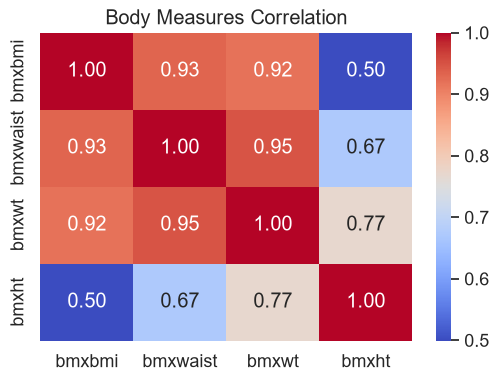

In [26]:
      # Body measures correlation
body_corr_cols = ["bmxbmi", "bmxwaist", "bmxwt", "bmxht"]

plt.figure(figsize=(6, 4))

sns.heatmap(
    bmx[body_corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Body Measures Correlation")
plt.show()

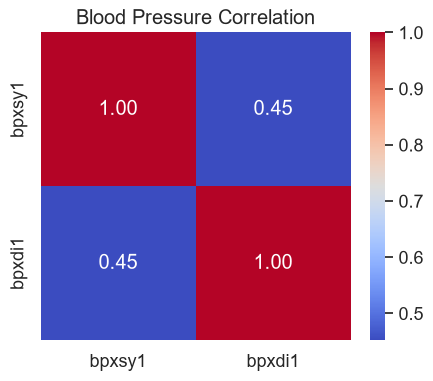

In [27]:
# Blood pressure correlation

bp_corr_cols = ["bpxsy1", "bpxdi1"]

plt.figure(figsize=(5, 4))

sns.heatmap(
    bpx[bp_corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Blood Pressure Correlation")
plt.show()

### STEP 11 - Cross Dataset EDA Summary


In [28]:

print("CARDIOMETABOLIC RISK EDA SUMMARY")
print("-" * 50)

print(f"Total participants in DEMO dataset: {demo.shape[0]:,}")
print(f"Average age: {demo['ridageyr'].mean():.1f}")
print(f"Average BMI: {bmx['bmxbmi'].mean():.1f}")
print(f"Average waist circumference: {bmx['bmxwaist'].mean():.1f}")
print(f"Average systolic BP: {bpx['bpxsy1'].mean():.1f}")
print(f"Average diastolic BP: {bpx['bpxdi1'].mean():.1f}")
print(f"Average fasting glucose: {glu['lbxglu'].mean():.1f}")
print(f"Average HbA1c: {ghb['lbxgh'].mean():.1f}")
print(f"Average total cholesterol: {tchol['lbxtc'].mean():.1f}")
print(f"Average HDL cholesterol: {hdl['lbdhdd'].mean():.1f}")
print(f"Average triglycerides: {trigly['lbxtr'].mean():.1f}")

CARDIOMETABOLIC RISK EDA SUMMARY
--------------------------------------------------
Total participants in DEMO dataset: 9,254
Average age: 34.3
Average BMI: 26.6
Average waist circumference: 89.9
Average systolic BP: 121.3
Average diastolic BP: 67.8
Average fasting glucose: 111.8
Average HbA1c: 5.8
Average total cholesterol: 179.9
Average HDL cholesterol: 53.4
Average triglycerides: 107.3
